# PEMS-XGBoost CO — optimización walk-forward R1_POC_EFFICIENT

**Propósito:** desarrollar y confirmar un regresor XGBoost exclusivamente
data-driven para CO mediante los folds anuales expansivos `WF01–WF03` del
protocolo `WF_PROTOCOL_R1`.

**Alcance:** búsqueda Optuna sobre DEV 2011–2014, tres folds temporales,
confirmación multisemilla y generación de `BEST_CONFIG`. El año 2015 permanece
cerrado: el notebook no exige el archivo, no lee su encabezado, no calcula su
hash y no materializa sus variables.

**Entradas:** `gt_2011.csv`–`gt_2014.csv` y los artefactos FROZEN de
`00_PEMS_PINN_WF_PROTOCOL - R1.ipynb`.

**Salidas:** estudio reanudable, tablas por fold, configuración ganadora,
política final de rondas, manifiesto FROZEN y handoff a
`07_XGBoost_CO_WF_FINAL - R1F_STD.ipynb`.

**Entorno previsto:** Google Colab; CPU o CUDA se selecciona una sola vez.
**Estado inicial:** DEVELOPMENT. Solo `FULL_AUTO` puede congelar resultados.

**Contrato científico:** nueve entradas RAW, `gbtree/hist`, objetivo
cuadrático, sin restricciones monotónicas, pérdida física, sintéticos,
selección de variables ni escalamiento de X. El protocolo gobierna únicamente
la partición temporal; su política de campaña PINN no se consume.

## Mapa del notebook

| Sección | Finalidad |
|---|---|
| SEC-01 | entorno, configuración, recursos y rutas |
| SEC-02 | autenticación del protocolo temporal FROZEN |
| SEC-03 | materialización exclusiva de DEV y folds WF |
| SEC-04 | núcleo XGBoost y controles unitarios |
| SEC-05 | anclas, espacio Optuna y evaluación completa |
| SEC-06 | estudio reanudable y parada adaptativa |
| SEC-07 | ranking y confirmación multisemilla |
| SEC-08 | congelamiento, evidencia DEV y handoff |

## SEC-01 — Entorno, dependencias y configuración

### C-01.01 — Bootstrap de Colab

**Objetivo:** declarar la raíz única, el modo de ejecución e instalar solo
dependencias ausentes. **Control:** `RUN_MODE=SMOKE` nunca congela.


In [1]:
# [C-01.01] Bootstrap de Colab
import importlib.metadata
import importlib.util
import os
import re
import subprocess
import sys
from pathlib import Path

PROJECT_ROOT_PATH = os.environ.get(
    "PEMS_PROJECT_ROOT",
    "/content/drive/MyDrive/Turbine_Emissions_PINN",
)
RUN_MODE = os.environ.get("PEMS_RUN_MODE", "SMOKE").upper()
DEVICE_PREFERENCE = os.environ.get("PEMS_XGB_DEVICE", "AUTO").upper()

if RUN_MODE not in {"SMOKE", "FULL_AUTO"}:
    raise ValueError("RUN_MODE debe ser SMOKE o FULL_AUTO")
if DEVICE_PREFERENCE not in {"AUTO", "CPU", "CUDA"}:
    raise ValueError("DEVICE_PREFERENCE debe ser AUTO, CPU o CUDA")

required_packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "sklearn": "scikit-learn",
    "matplotlib": "matplotlib",
    "optuna": "optuna",
    "xgboost": "xgboost>=2.0",
    "psutil": "psutil",
}
minimum_versions = {"xgboost": (2, 0)}


def major_minor(version_text: str) -> tuple[int, int]:
    numbers = [int(item) for item in re.findall(r"\d+", version_text)]
    return tuple((numbers + [0, 0])[:2])


missing_packages = []
for module, package in required_packages.items():
    if importlib.util.find_spec(module) is None:
        missing_packages.append(package)
        continue
    minimum = minimum_versions.get(module)
    if minimum is None:
        continue
    try:
        installed = importlib.metadata.version(module)
    except importlib.metadata.PackageNotFoundError:
        missing_packages.append(package)
        continue
    if major_minor(installed) < minimum:
        missing_packages.append(package)

if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )

IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").exists():
        drive.mount("/content/drive")

print(
    {
        "entorno": "Colab" if IN_COLAB else "local",
        "run_mode": RUN_MODE,
        "dependencias_instaladas": missing_packages,
    }
)


{'entorno': 'local', 'run_mode': 'FULL_AUTO', 'dependencias_instaladas': []}


### C-01.02 / CFG-01–CFG-04 — Configuración central

**Objetivo:** fijar el contrato científico y el presupuesto antes de leer
resultados. **Salida:** una sola fuente de verdad para la campaña.


In [2]:
# [C-01.02] Imports y configuración central
from dataclasses import dataclass
from datetime import datetime, timezone
import hashlib
import importlib.metadata
import json
import math
import platform
import random
import shutil
import tempfile
import time

import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import psutil
import xgboost as xgb
from IPython.display import display
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)

VERSION = "XGBOOST_CO_WF_OPT_R1_POC_EFFICIENT"
PROTOCOL_VERSION = "WF_PROTOCOL_R1"
CURRENT_NOTEBOOK_NAME = "07_XGBoost_CO_WF_OPT - R1_POC_EFFICIENT.ipynb"
UPSTREAM_NOTEBOOK_NAME = "00_PEMS_PINN_WF_PROTOCOL - R1.ipynb"
DOWNSTREAM_NOTEBOOK_NAME = "07_XGBoost_CO_WF_FINAL - R1F_STD.ipynb"

FEATURES = [
    "AT", "AP", "AH", "AFDP", "GTEP",
    "TIT", "TAT", "TEY", "CDP",
]
TARGET = "CO"
OTHER_TARGET = "NOX"
TARGET_TRANSFORMS = ["identity", "log1p"]
DEVELOPMENT_YEARS = [2011, 2012, 2013, 2014]
FINAL_TEST_YEAR = 2015
DEVELOPMENT_FOLD_NAMES = ["WF01", "WF02", "WF03"]
N_FOLDS = len(DEVELOPMENT_FOLD_NAMES)
SEARCH_SEED = 42
OPTUNA_SEED = 20260818

PURE_DATA_DRIVEN = {
    "pure_data_driven": True,
    "physics_loss": False,
    "synthetic_physics_samples": False,
    "monotone_constraints": None,
    "interaction_constraints": None,
    "other_pollutant_as_input": False,
    "feature_recipe": "RAW_9",
    "feature_scaler": None,
}

# CFG-01 — Núcleo fijo, no optimizable.
FIXED_XGB_PARAMETERS = {
    "booster": "gbtree",
    "tree_method": "hist",
    "grow_policy": "depthwise",
    "max_bin": 256,
    "objective": "reg:squarederror",
    "sampling_method": "uniform",
    "colsample_bylevel": 1.0,
    "colsample_bynode": 1.0,
    "verbosity": 0,
}

# CFG-02 — Early stopping se ajusta dentro de cada fold, nunca con 2015.
MAX_BOOST_ROUNDS_FULL = 4_000
EARLY_STOPPING_ROUNDS_FULL = 100
MAX_BOOST_ROUNDS_SMOKE = 200
EARLY_STOPPING_ROUNDS_SMOKE = 20

# CFG-03 — Presupuesto POC y parada práctica predeclarada.
INITIAL_OPTUNA_TRIALS = 30
MAX_TOTAL_OPTUNA_TRIALS = 55
ADAPTIVE_BLOCK_SIZE = 5
ADAPTIVE_PATIENCE_BLOCKS = 2
MIN_OBJECTIVE_IMPROVEMENT = 0.002
MIN_COMPLETE_TRIALS = 12

# CFG-04 — Confirmación y política final.
TOP_N_CONFIRMATION = 3
TOP_N_FINALISTS = 2
CONFIRMATION_SCREENING_SEEDS = [21, 42, 84]
CONFIRMATION_EXTENSION_SEEDS = [126, 168]
FINAL_SEEDS = [21, 42, 63, 84, 105, 126, 147, 168, 189, 210]
ENSEMBLE_RULE = "arithmetic_mean_all_predeclared_seeds"

# Optuna es serial. El paralelismo ocurre dentro de XGBoost en CPU o CUDA.
OPTUNA_N_JOBS = 1
FOLD_EXECUTION_POLICY = "ALL_THREE_WF_FOLDS_FOR_RANKABLE_EVIDENCE"
PARTIAL_TEMPORAL_SCREENING = False

RAW_DATA_REL = Path("data") / "raw"
PROTOCOL_REL = Path("models") / "wf" / "work_pinn_wf_protocol"
OUTPUT_REL = Path("models/wf/work_xgboost_co_wf_opt_r1_poc_efficient")

<USER_HOME>\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### C-01.03 / CHK-01 — Rutas, hashes y backend congelado

**Objetivo:** validar la raíz, crear salidas y seleccionar CPU/CUDA una sola
vez. El dispositivo es operativo y no participa en Optuna.


In [3]:
# [C-01.03] Utilidades, rutas y selección del backend
def utc_now() -> str:
    return datetime.now(timezone.utc).isoformat()


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()


def sha256_bytes(payload: bytes) -> str:
    return hashlib.sha256(payload).hexdigest()


def canonical_json_hash(payload: dict) -> str:
    encoded = json.dumps(
        payload,
        ensure_ascii=False,
        sort_keys=True,
        separators=(",", ":"),
    ).encode("utf-8")
    return sha256_bytes(encoded)


def atomic_text(path: Path, text: str) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(
        mode="w",
        encoding="utf-8",
        dir=path.parent,
        delete=False,
    ) as handle:
        handle.write(text)
        temporary = Path(handle.name)
    temporary.replace(path)


def atomic_json(path: Path, payload: dict) -> None:
    atomic_text(path, json.dumps(payload, ensure_ascii=False, indent=2))


def atomic_csv(path: Path, frame: pd.DataFrame) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    with tempfile.NamedTemporaryFile(
        mode="w",
        encoding="utf-8",
        newline="",
        dir=path.parent,
        delete=False,
    ) as handle:
        frame.to_csv(handle, index=False)
        temporary = Path(handle.name)
    temporary.replace(path)


@dataclass(frozen=True)
class CampaignPaths:
    work: Path
    audit: Path
    configs: Path
    figures: Path
    optuna: Path
    reports: Path
    tables: Path


def validate_project_root(path_value: str) -> Path:
    """Valida DEV y protocolo sin consultar la existencia de 2015."""
    root = Path(path_value).expanduser()
    if not root.is_absolute():
        raise ValueError("PROJECT_ROOT_PATH debe ser una ruta absoluta")
    root = root.resolve()
    required = [
        root / RAW_DATA_REL / f"gt_{year}.csv"
        for year in DEVELOPMENT_YEARS
    ]
    required.append(root / PROTOCOL_REL)
    missing = [str(path) for path in required if not path.exists()]
    if missing:
        raise FileNotFoundError(
            "PROJECT_ROOT_PATH no contiene DEV/protocolo canónicos: "
            + str(missing)
        )
    return root


def create_paths(root: Path) -> CampaignPaths:
    work = root / OUTPUT_REL
    values = CampaignPaths(
        work=work,
        audit=work / "audit",
        configs=work / "configs",
        figures=work / "figures",
        optuna=work / "optuna",
        reports=work / "reports",
        tables=work / "tables",
    )
    for path in values.__dict__.values():
        Path(path).mkdir(parents=True, exist_ok=True)
    return values


def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)


def select_device() -> str:
    if DEVICE_PREFERENCE == "CPU":
        return "cpu"
    wants_cuda = DEVICE_PREFERENCE == "CUDA" or (
        DEVICE_PREFERENCE == "AUTO" and shutil.which("nvidia-smi") is not None
    )
    if not wants_cuda:
        return "cpu"
    try:
        trial_model = xgb.XGBRegressor(
            n_estimators=2,
            max_depth=2,
            tree_method="hist",
            device="cuda",
            objective="reg:squarederror",
            verbosity=0,
        )
        x_probe = np.arange(64, dtype=np.float32).reshape(32, 2)
        y_probe = np.arange(32, dtype=np.float32)
        trial_model.fit(x_probe, y_probe, verbose=False)
        return "cuda"
    except (xgb.core.XGBoostError, RuntimeError) as exc:
        if DEVICE_PREFERENCE == "CUDA":
            raise RuntimeError("CUDA fue exigido pero el preflight falló") from exc
        return "cpu"


PROJECT_ROOT = validate_project_root(PROJECT_ROOT_PATH)
PATHS = create_paths(PROJECT_ROOT)
DEVICE = select_device()
XGB_N_JOBS = 1 if DEVICE == "cuda" else max(
    1,
    min(8, psutil.cpu_count(logical=False) or 1),
)
ACTIVE_MAX_BOOST_ROUNDS = (
    MAX_BOOST_ROUNDS_SMOKE if RUN_MODE == "SMOKE" else MAX_BOOST_ROUNDS_FULL
)
ACTIVE_EARLY_STOPPING_ROUNDS = (
    EARLY_STOPPING_ROUNDS_SMOKE
    if RUN_MODE == "SMOKE"
    else EARLY_STOPPING_ROUNDS_FULL
)
set_seed(SEARCH_SEED)

ENVIRONMENT = {
    "version": VERSION,
    "generated_at_utc": utc_now(),
    "run_mode": RUN_MODE,
    "device": DEVICE,
    "xgb_n_jobs": XGB_N_JOBS,
    "optuna_n_jobs": OPTUNA_N_JOBS,
    "parallelism": "XGBoost internal only; trials and folds serial",
    "python": sys.version,
    "platform": platform.platform(),
    "cpu_physical": psutil.cpu_count(logical=False),
    "cpu_logical": psutil.cpu_count(logical=True),
    "ram_gib": round(psutil.virtual_memory().total / 2**30, 3),
    "packages": {
        name: importlib.metadata.version(name)
        for name in [
            "numpy", "pandas", "scikit-learn", "optuna", "xgboost"
        ]
    },
}
atomic_json(PATHS.audit / "ENVIRONMENT_XGBOOST_CO_WF_R1.json", ENVIRONMENT)
display(pd.DataFrame([ENVIRONMENT]).T.rename(columns={0: "valor"}))

,valor
version,XGBOOST_CO_WF_OPT_R1_POC_EFFICIENT
generated_at_utc,2026-08-19T22:55:24.647014+00:00
run_mode,FULL_AUTO
device,cuda
xgb_n_jobs,1
optuna_n_jobs,1
parallelism,XGBoost internal only; trials and folds serial
python,"3.12.10 (tags/v3.12.10:0cc8128, Apr 8 2025, 1..."
platform,Windows-11-10.0.26200-SP0
cpu_physical,16


## SEC-02 — Contrato temporal FROZEN de `WF_PROTOCOL_R1`

### C-02.01 / CHK-02 — Autenticación sin acceso a 2015

**Objetivo:** verificar hashes, años, roles y folds compartidos.  
**Entradas:** manifests y assignment del protocolo WF.  
**Salidas:** asignación DEV autenticada y estado de linaje.  
**Detención:** cualquier divergencia del protocolo o permiso de lectura de 2015.

La política de campaña PINN del protocolo no gobierna XGBoost; este consumidor adopta el contrato temporal común y declara su propio
presupuesto antes de ejecutar Optuna.

In [4]:
# [C-02.01] Verificación del protocolo FROZEN
def verify_protocol(
    root: Path,
    paths: CampaignPaths,
) -> tuple[pd.DataFrame, dict, dict]:
    """Autentica el contrato temporal WF sin leer contenido de 2015."""
    base = root / PROTOCOL_REL
    required = {
        "protocol": base / "manifests" / "WF_PROTOCOL_MANIFEST.json",
        "folds": base / "manifests" / "WF_FOLDS_MANIFEST.json",
        "consumers": base / "manifests" / "WF_CONSUMER_CONTRACT.json",
        "general": (
            base / "manifests" / "MANIFIESTO_ARTEFACTOS_WF_PROTOCOL.json"
        ),
        "assignment": base / "tables" / "WF_DEVELOPMENT_ROW_ASSIGNMENT.csv",
        "fold_summary": base / "tables" / "WF_FOLDS_SUMMARY.csv",
    }
    missing = [str(path) for path in required.values() if not path.is_file()]
    if missing:
        raise FileNotFoundError(f"Artefactos FROZEN WF ausentes: {missing}")

    manifests = {
        name: json.loads(path.read_text(encoding="utf-8"))
        for name, path in required.items()
        if name not in {"assignment", "fold_summary"}
    }
    for name in ("protocol", "folds", "consumers", "general"):
        manifest = manifests[name]
        if manifest.get("status") != "FROZEN":
            raise RuntimeError(f"{name} no está FROZEN")
        if manifest.get("protocol_version") != PROTOCOL_VERSION:
            raise RuntimeError(f"Versión inesperada en {name}")

    indexed = {
        str(item["path"]).replace("\\", "/"): item["sha256"]
        for item in manifests["general"].get("artifacts", [])
    }
    canonical = {
        "manifests/WF_PROTOCOL_MANIFEST.json": required["protocol"],
        "manifests/WF_FOLDS_MANIFEST.json": required["folds"],
        "manifests/WF_CONSUMER_CONTRACT.json": required["consumers"],
        "tables/WF_DEVELOPMENT_ROW_ASSIGNMENT.csv": required["assignment"],
        "tables/WF_FOLDS_SUMMARY.csv": required["fold_summary"],
    }
    for relative, path in canonical.items():
        if indexed.get(relative) != sha256_file(path):
            raise RuntimeError(f"Artefacto no autenticado: {relative}")

    protocol = manifests["protocol"]
    folds_manifest = manifests["folds"]
    consumer = manifests["consumers"]
    if protocol.get("development_years") != DEVELOPMENT_YEARS:
        raise RuntimeError("Años DEV incompatibles")
    if int(protocol.get("final_test_year", -1)) != FINAL_TEST_YEAR:
        raise RuntimeError("Año TEST incompatible")
    if protocol.get("features") != FEATURES:
        raise RuntimeError("Features incompatibles")
    if protocol.get("fixed_parameters") != {
        "gap_records": 0,
        "temporal_weighting": "uniform",
    }:
        raise RuntimeError("Gap o ponderación temporal incompatibles")
    if folds_manifest.get("development_folds") != DEVELOPMENT_FOLD_NAMES:
        raise RuntimeError("Folds de desarrollo incompatibles")
    if folds_manifest.get("final_fold") != "WF04":
        raise RuntimeError("WF04 no está reservado para FINAL")

    common = consumer.get("common_contract", {})
    if common.get("scenario") != "ANNUAL_EXPANDING_WALK_FORWARD":
        raise RuntimeError("Escenario temporal inesperado")
    if common.get("opt_may_read_2015_features"):
        raise RuntimeError("El protocolo permite indebidamente X_2015")
    if common.get("opt_may_read_2015_targets"):
        raise RuntimeError("El protocolo permite indebidamente y_2015")
    if not common.get("final_may_open_2015_after_frozen_handoff"):
        raise RuntimeError("El protocolo no define la puerta FINAL")

    assignment_hash = sha256_file(required["assignment"])
    fold_summary_hash = sha256_file(required["fold_summary"])
    if assignment_hash != protocol.get("row_assignment_sha256"):
        raise RuntimeError("Hash de asignación inconsistente")
    if assignment_hash != folds_manifest.get("row_assignment_sha256"):
        raise RuntimeError("Hash de asignación distinto en folds")
    if fold_summary_hash != protocol.get("fold_summary_sha256"):
        raise RuntimeError("Hash del resumen de folds inconsistente")
    if fold_summary_hash != folds_manifest.get("fold_summary_sha256"):
        raise RuntimeError("Hash del resumen distinto en folds")

    assignment = pd.read_csv(required["assignment"])
    required_columns = {
        "global_row_id",
        "year",
        "row_in_year",
        "global_position",
        "WF01_role",
        "WF02_role",
        "WF03_role",
        "WF04_role",
    }
    if not required_columns.issubset(assignment.columns):
        raise ValueError("Asignación WF incompleta")
    if assignment.global_row_id.duplicated().any():
        raise RuntimeError("global_row_id no es único")
    if sorted(assignment.year.unique().tolist()) != DEVELOPMENT_YEARS:
        raise RuntimeError("La asignación contiene años no autorizados")
    if FINAL_TEST_YEAR in assignment.year.unique():
        raise RuntimeError("2015 aparece en la asignación DEV")

    expected_hashes = {
        int(item["year"]): item["sha256"]
        for item in protocol.get("development_data_hashes", [])
    }
    if set(expected_hashes) != set(DEVELOPMENT_YEARS):
        raise RuntimeError("El protocolo no declara los cuatro hashes DEV")
    for year in DEVELOPMENT_YEARS:
        raw_path = root / RAW_DATA_REL / f"gt_{year}.csv"
        if sha256_file(raw_path) != expected_hashes[year]:
            raise RuntimeError(f"Hash inesperado para gt_{year}.csv")

    audit = pd.DataFrame(
        [
            {
                "artifact": name,
                "path": str(path.relative_to(root)).replace("\\", "/"),
                "sha256": sha256_file(path),
            }
            for name, path in required.items()
        ]
    )
    atomic_csv(paths.audit / "PROTOCOL_INPUT_HASHES_XGBOOST_CO_WF_R1.csv", audit)
    status = {
        "protocol": "FROZEN",
        "assignment_sha256": assignment_hash,
        "fold_summary_sha256": fold_summary_hash,
        "general_manifest_sha256": sha256_file(required["general"]),
        "campaign_policy": "XGBOOST_R1_OWN_POLICY",
        "test_content_read": False,
        "test_content_hashed": False,
    }
    return assignment, manifests, status


ASSIGNMENT, PROTOCOL_MANIFESTS, PROTOCOL_STATUS = verify_protocol(
    PROJECT_ROOT,
    PATHS,
)
ASSIGNMENT_HASH = PROTOCOL_STATUS["assignment_sha256"]
FOLD_HASH = PROTOCOL_STATUS["fold_summary_sha256"]
print(
    {
        "CHK-02": "PASS",
        "rows_DEV": len(ASSIGNMENT),
        "folds": DEVELOPMENT_FOLD_NAMES,
        "2015_content_read": False,
    }
)

{'CHK-02': 'PASS', 'rows_DEV': 29349, 'folds': ['WF01', 'WF02', 'WF03'], '2015_content_read': False}


## SEC-03 — Materialización autorizada de DEV y folds anuales

### C-03.01 / ALG-01 / CHK-03 — Carga exclusiva de 2011–2014

**Lógica humana:**
1. autenticar cada CSV DEV contra el protocolo;
2. leer las nueve entradas y únicamente CO;
3. reconciliar el orden con el assignment FROZEN;
4. registrar explícitamente cero accesos a 2015 y a NOX.

In [5]:
# [C-03.01] Carga exclusiva de DEV
def load_dev_authorized(
    root: Path,
    assignment: pd.DataFrame,
    paths: CampaignPaths,
) -> tuple[pd.DataFrame, dict]:
    """Materializa FEATURES + CO solo para 2011–2014."""
    frames = []
    events = []
    expected_hashes = {
        int(item["year"]): item["sha256"]
        for item in PROTOCOL_MANIFESTS["protocol"]["development_data_hashes"]
    }
    role_columns = [f"{name}_role" for name in DEVELOPMENT_FOLD_NAMES]
    for year in DEVELOPMENT_YEARS:
        metadata = assignment.loc[assignment.year.eq(year)].sort_values(
            "row_in_year"
        )
        raw_path = root / RAW_DATA_REL / f"gt_{year}.csv"
        if sha256_file(raw_path) != expected_hashes[year]:
            raise RuntimeError(f"Hash DEV alterado en {year}")
        header = pd.read_csv(raw_path, nrows=0).columns.tolist()
        if not set(FEATURES + [TARGET, OTHER_TARGET]).issubset(header):
            raise ValueError(f"Columnas faltantes en {raw_path.name}")
        values = pd.read_csv(raw_path, usecols=FEATURES + [TARGET])[
            FEATURES + [TARGET]
        ]
        if len(values) != len(metadata):
            raise RuntimeError(f"Conteo no reconciliado en {year}")
        identity_columns = [
            "global_row_id",
            "year",
            "row_in_year",
            "global_position",
            *role_columns,
        ]
        frame = pd.concat(
            [
                metadata[identity_columns].reset_index(drop=True),
                values.reset_index(drop=True),
            ],
            axis=1,
        )
        frames.append(frame)
        events.append(
            {
                "year": year,
                "dev_rows_materialized": len(frame),
                "test_target_rows_materialized": 0,
                "test_feature_rows_materialized": 0,
                "other_pollutant_materialized": False,
            }
        )

    data = pd.concat(frames, ignore_index=True)
    if data.global_row_id.duplicated().any():
        raise RuntimeError("global_row_id duplicado en DEV")
    if sorted(data.year.unique().tolist()) != DEVELOPMENT_YEARS:
        raise RuntimeError("DEV contiene años no autorizados")
    if not np.isfinite(data[FEATURES + [TARGET]].to_numpy(float)).all():
        raise ValueError("DEV contiene NaN o infinito")
    if not data.global_row_id.astype(str).reset_index(drop=True).equals(
        assignment.global_row_id.astype(str).reset_index(drop=True)
    ):
        raise RuntimeError("DEV y assignment no conservan el mismo orden")

    audit = {
        "status": "PASS",
        "target": TARGET,
        "generated_at_utc": utc_now(),
        "development_years": DEVELOPMENT_YEARS,
        "dev_rows": len(data),
        "test_target_rows_materialized": 0,
        "test_feature_rows_materialized": 0,
        "test_content_sha256_computed": False,
        "other_pollutant_materialized": False,
        "events": events,
    }
    atomic_json(paths.audit / "TARGET_ACCESS_AUDIT_XGBOOST_CO_WF_R1.json", audit)
    return data, audit


DEV_DATA, TARGET_ACCESS_AUDIT = load_dev_authorized(
    PROJECT_ROOT,
    ASSIGNMENT,
    PATHS,
)
print(
    {
        "CHK-03": TARGET_ACCESS_AUDIT["status"],
        "DEV_rows": len(DEV_DATA),
        "TEST_y_rows": TARGET_ACCESS_AUDIT["test_target_rows_materialized"],
        "TEST_X_rows": TARGET_ACCESS_AUDIT["test_feature_rows_materialized"],
    }
)

{'CHK-03': 'PASS', 'DEV_rows': 29349, 'TEST_y_rows': 0, 'TEST_X_rows': 0}


### C-03.02 / ALG-02 / CHK-04 — Reconstrucción exacta de `WF01–WF03`

Cada fold se deriva de las columnas de roles FROZEN. TRAIN siempre antecede
estrictamente al año de validación; las filas `NOT_USED` no intervienen.

In [6]:
# [C-03.02] Reconstrucción y auditoría de folds
def reconstruct_folds(
    data: pd.DataFrame,
    assignment: pd.DataFrame,
) -> tuple[dict, pd.DataFrame]:
    """Reconstruye WF01–WF03 desde roles FROZEN y prueba cronología."""
    fold_specs = {
        item["fold"]: item
        for item in PROTOCOL_MANIFESTS["folds"].get("folds", [])
    }
    folds = {}
    rows = []
    for fold_id, fold_name in enumerate(DEVELOPMENT_FOLD_NAMES):
        role_column = f"{fold_name}_role"
        train_index = np.flatnonzero(
            assignment[role_column].eq("TRAIN").to_numpy()
        )
        validation_index = np.flatnonzero(
            assignment[role_column].eq("VALIDATION").to_numpy()
        )
        if not len(train_index) or not len(validation_index):
            raise RuntimeError(f"{fold_name} contiene una partición vacía")
        if np.intersect1d(train_index, validation_index).size:
            raise RuntimeError(f"{fold_name} contiene solapamiento")
        train_years = sorted(data.iloc[train_index].year.unique().tolist())
        validation_years = sorted(
            data.iloc[validation_index].year.unique().tolist()
        )
        spec = fold_specs.get(fold_name, {})
        if train_years != spec.get("train_years"):
            raise RuntimeError(f"{fold_name} no conserva sus años TRAIN")
        if validation_years != [spec.get("evaluation_year")]:
            raise RuntimeError(f"{fold_name} no conserva su año VALIDATION")
        if max(train_years) >= min(validation_years):
            raise RuntimeError(f"{fold_name} viola la cronología estricta")
        folds[fold_id] = (train_index, validation_index)
        rows.append(
            {
                "fold": fold_id,
                "fold_name": fold_name,
                "train_years": ",".join(map(str, train_years)),
                "validation_year": validation_years[0],
                "N_train": len(train_index),
                "N_validation": len(validation_index),
            }
        )
    if len(folds) != N_FOLDS:
        raise RuntimeError("Se requieren exactamente tres folds DEV")
    return folds, pd.DataFrame(rows)


FOLDS, FOLD_RECONSTRUCTION = reconstruct_folds(DEV_DATA, ASSIGNMENT)
atomic_csv(
    PATHS.tables / "FOLD_RECONSTRUCTION_XGBOOST_CO_WF_R1.csv",
    FOLD_RECONSTRUCTION,
)
display(FOLD_RECONSTRUCTION)

,fold,fold_name,train_years,validation_year,N_train,N_validation
0,0,WF01,2011,2012,7411,7628
1,1,WF02,"2011,2012",2013,15039,7152
2,2,WF03,"2011,2012,2013",2014,22191,7158


## SEC-04 — Núcleo XGBoost puramente data-driven

### C-04.01 / ALG-03 — Transformación del objetivo y métricas físicas

**Decisión:** NOx usa solo `identity`; CO permite `identity` o `log1p`.
Early stopping y todas las comparaciones se calculan después de volver a
mg/m³. No se recortan predicciones negativas.


In [7]:
# [C-04.01] Transformaciones y métricas en escala física
def target_forward(values, transform: str) -> np.ndarray:
    array = np.asarray(values, dtype=float)
    if transform == "identity":
        return array.copy()
    if transform == "log1p":
        if np.min(array) <= -1:
            raise ValueError("log1p requiere objetivo > -1")
        return np.log1p(array)
    raise ValueError(f"Transformación desconocida: {transform}")


def target_inverse(values, transform: str) -> np.ndarray:
    array = np.asarray(values, dtype=float)
    if transform == "identity":
        return array.copy()
    if transform == "log1p":
        return np.expm1(array)
    raise ValueError(f"Transformación desconocida: {transform}")


def physical_rmse_metric(transform: str):
    def physical_rmse(y_true_model, y_pred_model) -> float:
        y_true = target_inverse(y_true_model, transform)
        y_pred = target_inverse(y_pred_model, transform)
        return float(np.sqrt(mean_squared_error(y_true, y_pred)))

    physical_rmse.__name__ = "physical_rmse"
    return physical_rmse


def predictive_metrics(y_true, y_pred) -> dict:
    observed = np.asarray(y_true, dtype=float)
    predicted = np.asarray(y_pred, dtype=float)
    residual = predicted - observed
    threshold = float(np.quantile(observed, 0.90))
    tail = observed >= threshold
    return {
        "R2": float(r2_score(observed, predicted)),
        "RMSE": float(np.sqrt(mean_squared_error(observed, predicted))),
        "MAE": float(mean_absolute_error(observed, predicted)),
        "bias": float(np.mean(residual)),
        "negative_prediction_pct": float(np.mean(predicted < 0) * 100),
        "tail_threshold": threshold,
        "tail_RMSE": float(
            np.sqrt(mean_squared_error(observed[tail], predicted[tail]))
        ),
        "tail_MAE": float(mean_absolute_error(observed[tail], predicted[tail])),
        "tail_bias": float(np.mean(residual[tail])),
    }


### C-04.02 / ALG-04 — Entrenamiento de un fold

**Entradas:** configuración, fold y semilla. **Salidas:** métricas físicas,
`best_iteration` y complejidad. El callback conserva el mejor booster.


In [8]:
# [C-04.02] Entrenamiento XGBoost por fold
def model_parameters(config: dict, seed: int, with_early_stopping: bool):
    parameters = {
        **FIXED_XGB_PARAMETERS,
        "n_estimators": ACTIVE_MAX_BOOST_ROUNDS,
        "learning_rate": float(config["learning_rate"]),
        "max_depth": int(config["max_depth"]),
        "min_child_weight": float(config["min_child_weight"]),
        "gamma": float(config["gamma"]),
        "subsample": float(config["subsample"]),
        "colsample_bytree": float(config["colsample_bytree"]),
        "reg_alpha": float(config["reg_alpha"]),
        "reg_lambda": float(config["reg_lambda"]),
        "random_state": int(seed),
        "device": DEVICE,
        "n_jobs": XGB_N_JOBS,
        "eval_metric": physical_rmse_metric(config["target_transform"]),
    }
    if with_early_stopping:
        parameters["callbacks"] = [
            xgb.callback.EarlyStopping(
                rounds=ACTIVE_EARLY_STOPPING_ROUNDS,
                metric_name="physical_rmse",
                data_name="validation_0",
                maximize=False,
                save_best=True,
            )
        ]
    return parameters


def train_fold(
    config: dict,
    fold_id: int,
    seed: int,
) -> tuple[dict, xgb.XGBRegressor]:
    train_index, validation_index = FOLDS[fold_id]
    train = DEV_DATA.iloc[train_index]
    validation = DEV_DATA.iloc[validation_index]
    x_train = train[FEATURES]
    x_validation = validation[FEATURES]
    y_train = target_forward(train[TARGET], config["target_transform"])
    y_validation = target_forward(
        validation[TARGET],
        config["target_transform"],
    )

    started = time.perf_counter()
    model = xgb.XGBRegressor(
        **model_parameters(config, seed, with_early_stopping=True)
    )
    model.fit(
        x_train,
        y_train,
        eval_set=[(x_validation, y_validation)],
        verbose=False,
    )
    elapsed = time.perf_counter() - started
    best_iteration = int(model.best_iteration)
    prediction_model = model.predict(
        x_validation,
        iteration_range=(0, best_iteration + 1),
    )
    prediction = target_inverse(
        prediction_model,
        config["target_transform"],
    )
    metrics = predictive_metrics(validation[TARGET], prediction)
    booster = model.get_booster()
    tree_frame = booster.trees_to_dataframe()
    result = {
        "fold": int(fold_id),
        "seed": int(seed),
        "N_train": len(train),
        "N_validation": len(validation),
        "best_iteration": best_iteration,
        "effective_trees": best_iteration + 1,
        "nodes": int(len(tree_frame)),
        "leaves": int(tree_frame.Feature.eq("Leaf").sum()),
        "model_ubj_bytes": int(len(booster.save_raw(raw_format="ubj"))),
        "elapsed_seconds": float(elapsed),
        **metrics,
    }
    return result, model


def aggregate_fold_results(frame: pd.DataFrame) -> dict:
    if frame.empty:
        raise ValueError("No existen resultados de folds")
    r2_values = frame["R2"].to_numpy(float)
    return {
        "completed_folds": int(frame.fold.nunique()),
        "R2_min": float(np.min(r2_values)),
        "R2_median": float(np.median(r2_values)),
        "R2_mean": float(np.mean(r2_values)),
        "R2_std": float(np.std(r2_values, ddof=0)),
        "RMSE_median": float(frame.RMSE.median()),
        "MAE_median": float(frame.MAE.median()),
        "abs_bias_median": float(frame.bias.abs().median()),
        "tail_RMSE_median": float(frame.tail_RMSE.median()),
        "negative_prediction_pct_mean": float(
            frame.negative_prediction_pct.mean()
        ),
        "best_iteration_median": float(frame.best_iteration.median()),
        "model_ubj_bytes_median": float(frame.model_ubj_bytes.median()),
        "objective": float(
            np.min(r2_values)
            + 0.25 * np.median(r2_values)
            - 0.05 * np.std(r2_values, ddof=0)
        ),
    }


### C-04.03 / CHK-05 — Pruebas mínimas del núcleo

**Control:** transformación reversible, métricas físicas y ausencia de
parámetros físicos o monotónicos en el constructor.


In [9]:
# [C-04.03] Pruebas unitarias de alto riesgo
probe = np.array([0.0, 1.0, 10.0], dtype=float)
for transform in TARGET_TRANSFORMS:
    reconstructed = target_inverse(target_forward(probe, transform), transform)
    if not np.allclose(probe, reconstructed, rtol=1e-10, atol=1e-10):
        raise AssertionError(f"Transformación no reversible: {transform}")

base_probe_config = {
    "learning_rate": 0.05,
    "max_depth": 4,
    "min_child_weight": 2.0,
    "gamma": 0.0,
    "subsample": 0.8,
    "colsample_bytree": 0.8,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
    "target_transform": "identity",
}
constructor_probe = model_parameters(
    base_probe_config,
    seed=42,
    with_early_stopping=False,
)
forbidden_parameters = {
    "monotone_constraints",
    "interaction_constraints",
    "physics_loss",
}
if forbidden_parameters & set(constructor_probe):
    raise AssertionError("El constructor contiene restricciones prohibidas")
if constructor_probe["tree_method"] != "hist":
    raise AssertionError("tree_method debe permanecer hist")
if len(FOLDS) != 3:
    raise AssertionError("El núcleo requiere WF01–WF03")
if TARGET_ACCESS_AUDIT["test_target_rows_materialized"] != 0:
    raise AssertionError("OPT materializó el target 2015")
if TARGET_ACCESS_AUDIT["test_feature_rows_materialized"] != 0:
    raise AssertionError("OPT materializó features 2015")
print(
    {
        "CHK-05": "PASS",
        "pure_data_driven": PURE_DATA_DRIVEN,
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
    }
)

{'CHK-05': 'PASS', 'pure_data_driven': {'pure_data_driven': True, 'physics_loss': False, 'synthetic_physics_samples': False, 'monotone_constraints': None, 'interaction_constraints': None, 'other_pollutant_as_input': False, 'feature_recipe': 'RAW_9', 'feature_scaler': None}, 'fold_execution_policy': 'ALL_THREE_WF_FOLDS_FOR_RANKABLE_EVIDENCE'}


## SEC-05 — Anclas y espacio de búsqueda

### C-05.01 / CFG-05 — Anclas RAW_9

Incluye modelos compacto, equilibrado, regularizado y un ancla de forma
bibliográfica. Esta última no centra ni restringe el espacio Optuna.


In [10]:
# [C-05.01] Configuraciones ancla predeclaradas
def make_anchor(
    anchor_id,
    learning_rate,
    max_depth,
    min_child_weight,
    gamma,
    subsample,
    colsample_bytree,
    reg_alpha,
    reg_lambda,
    target_transform,
):
    return {
        "candidate_id": anchor_id,
        "source": "ANCHOR",
        "learning_rate": learning_rate,
        "max_depth": max_depth,
        "min_child_weight": min_child_weight,
        "gamma": gamma,
        "subsample": subsample,
        "colsample_bytree": colsample_bytree,
        "reg_alpha": reg_alpha,
        "reg_lambda": reg_lambda,
        "target_transform": target_transform,
    }


ANCHOR_CONFIGS = []
for transform in TARGET_TRANSFORMS:
    ANCHOR_CONFIGS.extend(
        [
            make_anchor(
                f"ANCHOR_COMPACT_{transform}",
                0.08, 4, 4.0, 0.0, 0.85, 0.85, 0.0, 2.0, transform,
            ),
            make_anchor(
                f"ANCHOR_BALANCED_{transform}",
                0.04, 8, 8.0, 0.05, 0.80, 0.90, 1e-4, 10.0, transform,
            ),
            make_anchor(
                f"ANCHOR_REGULARIZED_{transform}",
                0.02, 12, 32.0, 0.20, 0.70, 0.75, 0.01, 50.0, transform,
            ),
            make_anchor(
                f"ANCHOR_LITERATURE_SHAPE_{transform}",
                0.405, 32, 61.63, 0.12, 1.0, 0.96, 0.0, 69.05, transform,
            ),
        ]
    )
display(pd.DataFrame(ANCHOR_CONFIGS))


,candidate_id,source,learning_rate,max_depth,min_child_weight,gamma,subsample,colsample_bytree,reg_alpha,reg_lambda,target_transform
0,ANCHOR_COMPACT_identity,ANCHOR,0.080,4,4.00,0.00,0.85,0.85,0.0000,2.00,identity
1,ANCHOR_BALANCED_identity,ANCHOR,0.040,8,8.00,0.05,0.80,0.90,0.0001,10.00,identity
2,ANCHOR_REGULARIZED_identity,ANCHOR,0.020,12,32.00,0.20,0.70,0.75,0.0100,50.00,identity
3,ANCHOR_LITERATURE_SHAPE_identity,ANCHOR,0.405,32,61.63,0.12,1.00,0.96,0.0000,69.05,identity
4,ANCHOR_COMPACT_log1p,ANCHOR,0.080,4,4.00,0.00,0.85,0.85,0.0000,2.00,log1p
5,ANCHOR_BALANCED_log1p,ANCHOR,0.040,8,8.00,0.05,0.80,0.90,0.0001,10.00,log1p
6,ANCHOR_REGULARIZED_log1p,ANCHOR,0.020,12,32.00,0.20,0.70,0.75,0.0100,50.00,log1p
7,ANCHOR_LITERATURE_SHAPE_log1p,ANCHOR,0.405,32,61.63,0.12,1.00,0.96,0.0000,69.05,log1p


### C-05.02 / CFG-06 — Espacio Optuna focalizado

Se optimizan ocho hiperparámetros nativos y, solo para CO, la transformación
del objetivo. `n_estimators`, `max_bin`, backend y receta de variables no
forman parte de la búsqueda.


In [11]:
# [C-05.02] Muestreo del espacio científico R1
def suggest_zero_or_log(trial, name: str, upper: float) -> float:
    is_active = trial.suggest_categorical(f"{name}_active", [False, True])
    if not is_active:
        return 0.0
    return float(trial.suggest_float(f"{name}_nonzero", 1e-8, upper, log=True))


def sample_config(trial: optuna.Trial) -> dict:
    return {
        "candidate_id": f"OPTUNA_{trial.number:04d}",
        "source": "OPTUNA",
        "learning_rate": float(
            trial.suggest_float("learning_rate", 0.005, 0.30, log=True)
        ),
        "max_depth": int(trial.suggest_int("max_depth", 2, 16)),
        "min_child_weight": float(
            trial.suggest_float("min_child_weight", 0.5, 256.0, log=True)
        ),
        "gamma": suggest_zero_or_log(trial, "gamma", 20.0),
        "subsample": float(trial.suggest_float("subsample", 0.55, 1.0)),
        "colsample_bytree": float(
            trial.suggest_float("colsample_bytree", 0.55, 1.0)
        ),
        "reg_alpha": suggest_zero_or_log(trial, "reg_alpha", 10.0),
        "reg_lambda": float(
            trial.suggest_float("reg_lambda", 1e-3, 1e3, log=True)
        ),
        "target_transform": trial.suggest_categorical(
            "target_transform",
            TARGET_TRANSFORMS,
        ),
    }


def evaluate_candidate(
    config: dict,
    seed: int,
    fold_order: list[int],
    trial: optuna.Trial | None = None,
) -> tuple[pd.DataFrame, dict]:
    """Evalúa todos los folds solicitados; no aplica screening temporal parcial."""
    rows = []
    for step, fold_id in enumerate(fold_order):
        fold_result, _ = train_fold(config, fold_id, seed)
        rows.append({"candidate_id": config["candidate_id"], **fold_result})
        if trial is not None:
            partial_summary = aggregate_fold_results(pd.DataFrame(rows))
            trial.report(partial_summary["objective"], step=step)
            if trial.should_prune():
                raise RuntimeError("NopPruner no debe podar un trial WF")
    result_frame = pd.DataFrame(rows)
    return result_frame, aggregate_fold_results(result_frame)

## SEC-06 — Optuna reanudable y parada adaptativa

### C-06.01 / ALG-05 — Anclas y objetivo temporal robusto

En `SMOKE` y `FULL_AUTO`, cada ancla y trial completa `WF01–WF03`. SMOKE
reduce únicamente rondas y número de trials. No se usa poda ni screening por una
frontera temporal parcial.

In [12]:
# [C-06.01] Evaluación de anclas y función objetivo
ACTIVE_FOLD_ORDER = list(range(N_FOLDS))
ACTIVE_ANCHOR_CONFIGS = (
    ANCHOR_CONFIGS
    if RUN_MODE == "FULL_AUTO"
    else [
        config
        for config in ANCHOR_CONFIGS
        if config["candidate_id"].startswith("ANCHOR_COMPACT_")
    ]
)
expected_anchor_count = len(TARGET_TRANSFORMS) if RUN_MODE == "SMOKE" else 8
if len(ACTIVE_ANCHOR_CONFIGS) != expected_anchor_count:
    raise RuntimeError("Conteo de anchors activo incompatible con RUN_MODE")
anchor_fold_frames = []
anchor_summaries = []
for anchor in ACTIVE_ANCHOR_CONFIGS:
    fold_frame, summary = evaluate_candidate(
        anchor,
        seed=SEARCH_SEED,
        fold_order=ACTIVE_FOLD_ORDER,
    )
    anchor_fold_frames.append(fold_frame)
    anchor_summaries.append({**anchor, **summary})

ANCHOR_FOLDS = pd.concat(anchor_fold_frames, ignore_index=True)
ANCHOR_SUMMARY = pd.DataFrame(anchor_summaries)
atomic_csv(PATHS.tables / "ANCHOR_FOLDS_XGBOOST_CO_WF_R1.csv", ANCHOR_FOLDS)
atomic_csv(
    PATHS.tables / "ANCHOR_SUMMARY_XGBOOST_CO_WF_R1.csv",
    ANCHOR_SUMMARY,
)


def objective(trial: optuna.Trial) -> float:
    config = sample_config(trial)
    fold_frame, summary = evaluate_candidate(
        config,
        seed=SEARCH_SEED,
        fold_order=ACTIVE_FOLD_ORDER,
        trial=trial,
    )
    trial.set_user_attr("config", config)
    trial.set_user_attr("summary", summary)
    trial.set_user_attr(
        "fold_results",
        json.loads(fold_frame.to_json(orient="records")),
    )
    return float(summary["objective"])


print(
    {
        "active_anchor_count": len(ACTIVE_ANCHOR_CONFIGS),
        "active_anchor_ids": [
            config["candidate_id"] for config in ACTIVE_ANCHOR_CONFIGS
        ],
        "folds_per_anchor": len(ACTIVE_FOLD_ORDER),
    }
)
display(
    ANCHOR_SUMMARY[
        [
            "candidate_id",
            "target_transform",
            "completed_folds",
            "R2_min",
            "R2_median",
            "RMSE_median",
            "objective",
        ]
    ].sort_values("objective", ascending=False)
)

{'active_anchor_count': 8, 'active_anchor_ids': ['ANCHOR_COMPACT_identity', 'ANCHOR_BALANCED_identity', 'ANCHOR_REGULARIZED_identity', 'ANCHOR_LITERATURE_SHAPE_identity', 'ANCHOR_COMPACT_log1p', 'ANCHOR_BALANCED_log1p', 'ANCHOR_REGULARIZED_log1p', 'ANCHOR_LITERATURE_SHAPE_log1p'], 'folds_per_anchor': 3}


,candidate_id,target_transform,completed_folds,R2_min,R2_median,RMSE_median,objective
0,ANCHOR_COMPACT_identity,identity,3,0.561430,0.591184,1.293120,0.706231
1,ANCHOR_BALANCED_identity,identity,3,0.539307,0.597394,1.289790,0.685283
3,ANCHOR_LITERATURE_SHAPE_identity,identity,3,0.539881,0.568749,1.321612,0.678877
5,ANCHOR_BALANCED_log1p,log1p,3,0.515880,0.636616,1.314576,0.671380
4,ANCHOR_COMPACT_log1p,log1p,3,0.522545,0.607677,1.323002,0.671112
2,ANCHOR_REGULARIZED_identity,identity,3,0.524850,0.534543,1.383308,0.654577
7,ANCHOR_LITERATURE_SHAPE_log1p,log1p,3,0.471557,0.590705,1.346701,0.615052
6,ANCHOR_REGULARIZED_log1p,log1p,3,0.467634,0.588186,1.330177,0.610267


### C-06.02 / ALG-06 / ART-01 — SQLite y campaña serial

Optuna usa un único worker para proteger SQLite y evitar sobreasignación. La
aceleración ocurre dentro de XGBoost: CUDA si el preflight la valida o varios
hilos CPU en caso contrario.

In [13]:
# [C-06.02] Estudio persistente, fingerprint y parada adaptativa
SEARCH_SPACE_CONTRACT = {
    "learning_rate": [0.005, 0.30, "log"],
    "max_depth": [2, 16, "integer"],
    "min_child_weight": [0.5, 256.0, "log"],
    "gamma": [0.0, 1e-8, 20.0, "zero_or_log"],
    "subsample": [0.55, 1.0, "uniform"],
    "colsample_bytree": [0.55, 1.0, "uniform"],
    "reg_alpha": [0.0, 1e-8, 10.0, "zero_or_log"],
    "reg_lambda": [1e-3, 1e3, "log"],
    "target_transform": TARGET_TRANSFORMS,
}
OBJECTIVE_CONTRACT = {
    "direction": "maximize",
    "formula": "R2_min + 0.25*R2_median - 0.05*R2_std",
    "folds": DEVELOPMENT_FOLD_NAMES,
    "partial_temporal_screening": PARTIAL_TEMPORAL_SCREENING,
}
STUDY_FINGERPRINT_PAYLOAD = {
    "version": VERSION,
    "target": TARGET,
    "active_anchor_ids": [
        config["candidate_id"] for config in ACTIVE_ANCHOR_CONFIGS
    ],
    "active_anchor_count": len(ACTIVE_ANCHOR_CONFIGS),
    "protocol_version": PROTOCOL_VERSION,
    "protocol_general_manifest_sha256": PROTOCOL_STATUS[
        "general_manifest_sha256"
    ],
    "row_assignment_sha256": ASSIGNMENT_HASH,
    "fold_summary_sha256": FOLD_HASH,
    "search_space": SEARCH_SPACE_CONTRACT,
    "objective": OBJECTIVE_CONTRACT,
    "fixed_xgb_parameters": FIXED_XGB_PARAMETERS,
    "search_seed": SEARCH_SEED,
    "optuna_seed": OPTUNA_SEED,
    "confirmation_screening_seeds": CONFIRMATION_SCREENING_SEEDS,
    "confirmation_extension_seeds": CONFIRMATION_EXTENSION_SEEDS,
    "final_seeds": FINAL_SEEDS,
    "run_mode": RUN_MODE,
    "max_boost_rounds": ACTIVE_MAX_BOOST_ROUNDS,
    "early_stopping_rounds": ACTIVE_EARLY_STOPPING_ROUNDS,
    "backend": DEVICE,
    "xgb_n_jobs": XGB_N_JOBS,
    "optuna_n_jobs": OPTUNA_N_JOBS,
    "xgboost_version": xgb.__version__,
}
STUDY_FINGERPRINT = canonical_json_hash(STUDY_FINGERPRINT_PAYLOAD)
fingerprint_path = (
    PATHS.audit / f"STUDY_FINGERPRINT_XGBOOST_CO_WF_{RUN_MODE}_R1.json"
)

storage_path = PATHS.optuna / f"{TARGET}_XGBOOST_WF_{RUN_MODE}_R1.sqlite"
storage_url = "sqlite:///" + str(storage_path).replace("\\", "/")
study = optuna.create_study(
    study_name=f"{TARGET}_XGBOOST_WF_{RUN_MODE}_R1",
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=OPTUNA_SEED, multivariate=True),
    pruner=optuna.pruners.NopPruner(),
    storage=storage_url,
    load_if_exists=True,
)

# La autenticación ocurre inmediatamente después de abrir SQLite y antes de
# evaluar o añadir un solo trial.
existing_attrs = dict(study.system_attrs)
existing_fingerprint = existing_attrs.get("study_fingerprint_sha256")
existing_payload = existing_attrs.get("study_fingerprint_payload")
if existing_fingerprint is None:
    if study.trials:
        raise RuntimeError(
            "SQLite preexistente sin fingerprint; no es seguro reanudarlo"
        )
    study.set_system_attr("study_fingerprint_sha256", STUDY_FINGERPRINT)
    study.set_system_attr(
        "study_fingerprint_payload",
        STUDY_FINGERPRINT_PAYLOAD,
    )
elif (
    existing_fingerprint != STUDY_FINGERPRINT
    or existing_payload != STUDY_FINGERPRINT_PAYLOAD
):
    raise RuntimeError(
        "Fingerprint SQLite incompatible con protocolo, espacio o backend"
    )

authenticated_attrs = dict(study.system_attrs)
if (
    authenticated_attrs.get("study_fingerprint_sha256") != STUDY_FINGERPRINT
    or authenticated_attrs.get("study_fingerprint_payload")
    != STUDY_FINGERPRINT_PAYLOAD
):
    raise RuntimeError("El fingerprint no quedó autenticado en system_attrs")
atomic_json(
    fingerprint_path,
    {
        "status": "AUTHENTICATED",
        "generated_at_utc": utc_now(),
        "storage_path": str(storage_path.relative_to(PROJECT_ROOT)).replace(
            "\\", "/"
        ),
        "study_name": study.study_name,
        "study_fingerprint_sha256": STUDY_FINGERPRINT,
        "study_fingerprint_payload": STUDY_FINGERPRINT_PAYLOAD,
        "trials_at_authentication": len(study.trials),
    },
)


def attempted_trials(current_study) -> int:
    terminal = {
        optuna.trial.TrialState.COMPLETE,
        optuna.trial.TrialState.PRUNED,
        optuna.trial.TrialState.FAIL,
    }
    return sum(trial.state in terminal for trial in current_study.trials)


def complete_trials(current_study) -> int:
    return sum(
        trial.state == optuna.trial.TrialState.COMPLETE
        for trial in current_study.trials
    )


STOP_HISTORY = []
if RUN_MODE == "SMOKE":
    remaining = max(0, 2 - attempted_trials(study))
    if remaining:
        study.optimize(
            objective,
            n_trials=remaining,
            n_jobs=OPTUNA_N_JOBS,
            gc_after_trial=True,
        )
    CAMPAIGN_COMPLETE = False
    STOP_REASON = "SMOKE_ONLY_NO_FREEZE"
else:
    stale_blocks = 0
    previous_best = study.best_value if complete_trials(study) else -np.inf
    while attempted_trials(study) < MAX_TOTAL_OPTUNA_TRIALS:
        attempted_before = attempted_trials(study)
        if attempted_before < INITIAL_OPTUNA_TRIALS:
            block = min(
                INITIAL_OPTUNA_TRIALS - attempted_before,
                MAX_TOTAL_OPTUNA_TRIALS - attempted_before,
            )
        else:
            block = min(
                ADAPTIVE_BLOCK_SIZE,
                MAX_TOTAL_OPTUNA_TRIALS - attempted_before,
            )
        study.optimize(
            objective,
            n_trials=block,
            n_jobs=OPTUNA_N_JOBS,
            gc_after_trial=True,
        )
        current_best = study.best_value if complete_trials(study) else -np.inf
        improvement = current_best - previous_best
        if attempted_trials(study) >= INITIAL_OPTUNA_TRIALS:
            stale_blocks = (
                stale_blocks + 1
                if improvement < MIN_OBJECTIVE_IMPROVEMENT
                else 0
            )
        STOP_HISTORY.append(
            {
                "attempted": attempted_trials(study),
                "complete": complete_trials(study),
                "best_objective": current_best,
                "block_improvement": improvement,
                "stale_blocks": stale_blocks,
            }
        )
        previous_best = max(previous_best, current_best)
        if (
            attempted_trials(study) >= INITIAL_OPTUNA_TRIALS
            and complete_trials(study) >= MIN_COMPLETE_TRIALS
            and stale_blocks >= ADAPTIVE_PATIENCE_BLOCKS
        ):
            break
    CAMPAIGN_COMPLETE = (
        attempted_trials(study) >= INITIAL_OPTUNA_TRIALS
        and complete_trials(study) >= MIN_COMPLETE_TRIALS
    )
    STOP_REASON = (
        "PRACTICAL_CONVERGENCE"
        if stale_blocks >= ADAPTIVE_PATIENCE_BLOCKS
        else "MAX_TRIALS_REACHED"
    )

STOP_HISTORY_FRAME = pd.DataFrame(STOP_HISTORY)
atomic_csv(PATHS.tables / "STOP_HISTORY_XGBOOST_CO_WF_R1.csv", STOP_HISTORY_FRAME)
print(
    {
        "attempted": attempted_trials(study),
        "complete": complete_trials(study),
        "campaign_complete": CAMPAIGN_COMPLETE,
        "stop_reason": STOP_REASON,
        "optuna_n_jobs": OPTUNA_N_JOBS,
        "study_fingerprint": STUDY_FINGERPRINT,
    }
)

<USER_HOME>\AppData\Local\Temp\ipykernel_41600\1318550716.py:58: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  sampler=optuna.samplers.TPESampler(seed=OPTUNA_SEED, multivariate=True),


[I 2026-08-19 17:56:07,937] A new study created in RDB with name: CO_XGBOOST_WF_FULL_AUTO_R1


<USER_HOME>\AppData\Local\Temp\ipykernel_41600\1318550716.py:66: FutureWarning: system_attrs has been deprecated in v3.1.0. This feature will be removed in v5.0.0. See https://github.com/optuna/optuna/releases/tag/v3.1.0.
  existing_attrs = dict(study.system_attrs)
<USER_HOME>\AppData\Local\Temp\ipykernel_41600\1318550716.py:74: FutureWarning: set_system_attr has been deprecated in v3.1.0. This feature will be removed in v5.0.0. See https://github.com/optuna/optuna/releases/tag/v3.1.0.
  study.set_system_attr("study_fingerprint_sha256", STUDY_FINGERPRINT)
<USER_HOME>\AppData\Local\Temp\ipykernel_41600\1318550716.py:75: FutureWarning: set_system_attr has been deprecated in v3.1.0. This feature will be removed in v5.0.0. See https://github.com/optuna/optuna/releases/tag/v3.1.0.
  study.set_system_attr(
<USER_HOME>\AppData\Local\Temp\ipykernel_41600\1318550716.py:87: FutureWarning: system_attrs has been deprecated in v3.1.0. This feature will be removed in v5.0.0. See https://github.com/o

[I 2026-08-19 17:56:21,207] Trial 0 finished with value: 0.6649980868007812 and parameters: {'learning_rate': 0.218504539704629, 'max_depth': 15, 'min_child_weight': 1.298166890972207, 'gamma_active': False, 'subsample': 0.6145484157041747, 'colsample_bytree': 0.676885700915847, 'reg_alpha_active': False, 'reg_lambda': 0.0018207839875640825, 'target_transform': 'log1p'}. Best is trial 0 with value: 0.6649980868007812.


[I 2026-08-19 17:56:38,642] Trial 1 finished with value: 0.677208093335589 and parameters: {'learning_rate': 0.011782109870335913, 'max_depth': 12, 'min_child_weight': 55.22233714322687, 'gamma_active': True, 'gamma_nonzero': 0.8965686545554339, 'subsample': 0.6271832895533387, 'colsample_bytree': 0.7707068503761904, 'reg_alpha_active': False, 'reg_lambda': 0.355262990171629, 'target_transform': 'identity'}. Best is trial 1 with value: 0.677208093335589.


...

[I 2026-08-19 18:00:31,548] Trial 36 finished with value: 0.6328789533696904 and parameters: {'learning_rate': 0.08643801185070689, 'max_depth': 10, 'min_child_weight': 1.2611102013359285, 'gamma_active': True, 'gamma_nonzero': 0.057633149028580195, 'subsample': 0.9555486428876719, 'colsample_bytree': 0.729566992522449, 'reg_alpha_active': True, 'reg_alpha_nonzero': 0.00028388557750508536, 'reg_lambda': 0.7874058084573842, 'target_transform': 'identity'}. Best is trial 19 with value: 0.7033433972231129.


[I 2026-08-19 18:00:36,569] Trial 37 finished with value: 0.689147236499266 and parameters: {'learning_rate': 0.1971995758273342, 'max_depth': 13, 'min_child_weight': 2.201909560957302, 'gamma_active': False, 'subsample': 0.8681136168672883, 'colsample_bytree': 0.8192462315092125, 'reg_alpha_active': False, 'reg_lambda': 0.0028166729926698943, 'target_transform': 'identity'}. Best is trial 19 with value: 0.7033433972231129.


[I 2026-08-19 18:00:38,069] Trial 38 finished with value: 0.6119703478578414 and parameters: {'learning_rate': 0.18975387218907086, 'max_depth': 5, 'min_child_weight': 1.1285441036904513, 'gamma_active': True, 'gamma_nonzero': 8.338909205571762e-07, 'subsample': 0.8132816180945146, 'colsample_bytree': 0.6053035274300915, 'reg_alpha_active': False, 'reg_lambda': 0.00165086431048834, 'target_transform': 'identity'}. Best is trial 19 with value: 0.7033433972231129.


[I 2026-08-19 18:00:40,348] Trial 39 finished with value: 0.612941298698942 and parameters: {'learning_rate': 0.1705398795035708, 'max_depth': 8, 'min_child_weight': 1.501715522311261, 'gamma_active': True, 'gamma_nonzero': 0.0004747405653520396, 'subsample': 0.8175439784997052, 'colsample_bytree': 0.8461801839014594, 'reg_alpha_active': True, 'reg_alpha_nonzero': 0.3817257642892556, 'reg_lambda': 0.013358588738918351, 'target_transform': 'identity'}. Best is trial 19 with value: 0.7033433972231129.


{'attempted': 40, 'complete': 40, 'campaign_complete': True, 'stop_reason': 'PRACTICAL_CONVERGENCE', 'optuna_n_jobs': 1, 'study_fingerprint': 'd3cf1868be5d10fa39f114fca129aad0701e64a61d8cc67bb1f6dc97076c9f50'}


### C-06.03 / TAB-01 — Reconstrucción de tablas Optuna

Distingue ensayos completos, podados y fallidos; `n_trials` no se wfreta
como número de configuraciones completas.


In [14]:
# [C-06.03] Tablas persistentes de trials y folds
trial_rows = []
optuna_fold_rows = []
for frozen_trial in study.trials:
    row = {
        "trial_number": frozen_trial.number,
        "state": frozen_trial.state.name,
        "value": frozen_trial.value,
        **frozen_trial.params,
    }
    summary = frozen_trial.user_attrs.get("summary", {})
    row.update(summary)
    trial_rows.append(row)
    for fold_row in frozen_trial.user_attrs.get("fold_results", []):
        optuna_fold_rows.append(
            {"trial_number": frozen_trial.number, **fold_row}
        )
    for fold_row in frozen_trial.user_attrs.get(
        "partial_fold_results", []
    ):
        optuna_fold_rows.append(
            {"trial_number": frozen_trial.number, **fold_row}
        )

TRIALS_TABLE = pd.DataFrame(trial_rows)
OPTUNA_FOLDS_TABLE = pd.DataFrame(optuna_fold_rows)
atomic_csv(
    PATHS.tables / "OPTUNA_TRIALS_XGBOOST_CO_WF_R1.csv",
    TRIALS_TABLE,
)
atomic_csv(
    PATHS.tables / "OPTUNA_FOLDS_XGBOOST_CO_WF_R1.csv",
    OPTUNA_FOLDS_TABLE,
)
display(TRIALS_TABLE.tail(10))

,trial_number,state,value,learning_rate,max_depth,min_child_weight,gamma_active,subsample,colsample_bytree,reg_alpha_active,...,RMSE_median,MAE_median,abs_bias_median,tail_RMSE_median,negative_prediction_pct_mean,best_iteration_median,model_ubj_bytes_median,objective,gamma_nonzero,reg_alpha_nonzero
30,30,COMPLETE,0.525605,0.205265,5,2.980608,True,0.842690,0.740917,False,...,1.488400,0.884620,0.734416,4.038986,0.000000,102.0,76605.0,0.525605,1.030897e+01,NaN
31,31,COMPLETE,0.679211,0.185237,14,25.828028,False,0.820104,0.737430,False,...,1.351066,0.787770,0.384598,3.361620,0.004370,15.0,298121.0,0.679211,NaN,NaN
32,32,COMPLETE,0.662571,0.247815,14,2.011480,True,0.928393,0.941384,False,...,1.417725,0.880586,0.413845,3.516011,0.004661,6.0,690418.0,0.662571,9.776923e-03,NaN
33,33,COMPLETE,0.697135,0.024742,7,1.575359,True,0.683818,0.751150,False,...,1.300892,0.767437,0.524074,3.356536,0.000000,143.0,229085.0,0.697135,1.898080e+01,NaN
34,34,COMPLETE,0.594134,0.183013,8,0.749977,False,0.689746,0.768385,False,...,1.333858,0.807508,0.403515,3.372503,0.000000,8.0,93627.0,0.594134,NaN,NaN
35,35,COMPLETE,0.529918,0.062579,11,0.586090,False,0.955041,0.838987,False,...,1.428406,0.833121,0.461447,3.416821,0.000000,17.0,1202765.0,0.529918,NaN,NaN
36,36,COMPLETE,0.632879,0.086438,10,1.261110,True,0.955549,0.729567,True,...,1.353357,0.797791,0.424061,3.301998,0.000000,55.0,855929.0,0.632879,5.763315e-02,0.000284
37,37,COMPLETE,0.689147,0.197200,13,2.201910,False,0.868114,0.819246,False,...,1.333651,0.823904,0.381254,3.367906,0.000000,12.0,545850.0,0.689147,NaN,NaN
38,38,COMPLETE,0.611970,0.189754,5,1.128544,True,0.813282,0.605304,False,...,1.386986,0.776865,0.404311,3.367636,0.000000,16.0,42912.0,0.611970,8.338909e-07,NaN
39,39,COMPLETE,0.612941,0.170540,8,1.501716,True,0.817544,0.846180,True,...,1.354539,0.817481,0.379987,3.383803,0.000000,18.0,159029.0,0.612941,4.747406e-04,0.381726


## SEC-07 — Ranking y confirmación multisemilla

### C-07.01 / ALG-07 — Ranking jerárquico de candidatos

**Orden:** tres folds completos; mayor R² mínimo; mayor mediana de R²;
menor RMSE/MAE/sesgo; menor dispersión; bytes como desempate.


In [15]:
# [C-07.01] Ranking DEV-only
def rank_candidates(frame: pd.DataFrame) -> pd.DataFrame:
    ranked = frame.loc[frame.completed_folds.eq(N_FOLDS)].copy()
    if ranked.empty:
        return ranked
    ranked = ranked.sort_values(
        [
            "R2_min",
            "R2_median",
            "RMSE_median",
            "MAE_median",
            "abs_bias_median",
            "R2_std",
            "model_ubj_bytes_median",
        ],
        ascending=[False, False, True, True, True, True, True],
        kind="mergesort",
    ).reset_index(drop=True)
    ranked.insert(0, "rank", np.arange(1, len(ranked) + 1))
    return ranked


candidate_rows = ANCHOR_SUMMARY.to_dict(orient="records")
candidate_configs = {
    config["candidate_id"]: config.copy() for config in ANCHOR_CONFIGS
}
for frozen_trial in study.trials:
    if frozen_trial.state != optuna.trial.TrialState.COMPLETE:
        continue
    config = frozen_trial.user_attrs.get("config")
    summary = frozen_trial.user_attrs.get("summary")
    if config and summary:
        candidate_rows.append({**config, **summary})
        candidate_configs[config["candidate_id"]] = config

DEVELOPMENT_CANDIDATES = pd.DataFrame(candidate_rows)
DEVELOPMENT_RANKING = rank_candidates(DEVELOPMENT_CANDIDATES)
atomic_csv(
    PATHS.tables / "DEVELOPMENT_RANKING_XGBOOST_CO_WF_R1.csv",
    DEVELOPMENT_RANKING,
)
if RUN_MODE == "FULL_AUTO" and DEVELOPMENT_RANKING.empty:
    raise RuntimeError("Ningún candidato completó WF01–WF03")
display(DEVELOPMENT_RANKING.head(10))

,rank,candidate_id,source,learning_rate,max_depth,min_child_weight,gamma,subsample,colsample_bytree,reg_alpha,...,R2_mean,R2_std,RMSE_median,MAE_median,abs_bias_median,tail_RMSE_median,negative_prediction_pct_mean,best_iteration_median,model_ubj_bytes_median,objective
0,1,ANCHOR_COMPACT_identity,ANCHOR,0.080000,4,4.000000,0.000000,0.850000,0.850000,0.000000e+00,...,0.617779,0.059894,1.293120,0.769772,0.521989,3.354906,0.000000,59.0,97059.0,0.706231
1,2,OPTUNA_0033,OPTUNA,0.024742,7,1.575359,18.980802,0.683818,0.751150,0.000000e+00,...,0.612299,0.064013,1.300892,0.767437,0.524074,3.356536,0.000000,143.0,229085.0,0.697135
2,3,OPTUNA_0019,OPTUNA,0.298092,16,3.151997,0.000000,0.874723,0.745750,0.000000e+00,...,0.613893,0.049538,1.352641,0.853494,0.415559,3.357275,0.149448,9.0,625328.0,0.703343
3,4,OPTUNA_0025,OPTUNA,0.169856,8,2.843218,18.170950,0.783081,0.756811,0.000000e+00,...,0.622097,0.062100,1.290689,0.759046,0.488367,3.374638,0.000000,123.0,127768.0,0.700783
4,5,OPTUNA_0017,OPTUNA,0.201764,12,2.554954,0.000000,0.845269,0.832781,0.000000e+00,...,0.611666,0.052364,1.342373,0.830763,0.408015,3.394182,0.008740,12.0,384758.0,0.698787
5,6,OPTUNA_0012,OPTUNA,0.156598,8,2.859023,0.000035,0.918329,0.735699,8.454230e-03,...,0.620338,0.062311,1.294137,0.794980,0.415122,3.260355,0.000000,20.0,184349.0,0.698239
6,7,OPTUNA_0029,OPTUNA,0.274214,16,6.341359,0.000000,0.772059,0.815173,0.000000e+00,...,0.605220,0.063426,1.308796,0.825251,0.504156,3.402001,0.000000,30.0,1070598.0,0.687960
7,8,OPTUNA_0010,OPTUNA,0.054816,14,90.481638,0.000112,0.874290,0.722452,1.048132e-08,...,0.596631,0.067074,1.344029,0.785369,0.386933,3.421571,0.000000,65.0,464776.0,0.681497
8,9,OPTUNA_0006,OPTUNA,0.020175,9,5.355179,0.000000,0.620206,0.589552,4.183568e-03,...,0.605910,0.067017,1.313987,0.788074,0.372536,3.318219,0.000000,212.0,2437695.0,0.686292
9,10,OPTUNA_0031,OPTUNA,0.185237,14,25.828028,0.000000,0.820104,0.737430,0.000000e+00,...,0.596438,0.070760,1.351066,0.787770,0.384598,3.361620,0.004370,15.0,298121.0,0.679211


### C-07.02 / ALG-08 — Confirmación Top-3 × 3 y Top-2 × 5 semillas

Las semillas están predeclaradas. Ninguna se elige por su resultado y TEST
sigue cerrado. SMOKE omite esta etapa y no produce handoff.


In [16]:
# [C-07.02] Confirmación multisemilla escalonada
CONFIRMATION_RANKING_RULE = (
    "worst_fold_median_R2_desc_then_R2_q10_desc_then_R2_median_desc_"
    "R2_mean_desc_RMSE_MAE_bias_std_bytes_asc"
)


def confirm_candidates(candidate_ids: list[str], seeds: list[int]):
    fold_rows = []
    summary_rows = []
    for candidate_id in candidate_ids:
        config = candidate_configs[candidate_id]
        for seed in seeds:
            folds_frame, summary = evaluate_candidate(
                config,
                seed=seed,
                fold_order=list(range(N_FOLDS)),
            )
            fold_rows.append(folds_frame)
            summary_rows.append(
                {
                    "candidate_id": candidate_id,
                    "seed": seed,
                    **summary,
                }
            )
    return (
        pd.concat(fold_rows, ignore_index=True),
        pd.DataFrame(summary_rows),
    )


def rank_confirmation(fold_frame: pd.DataFrame) -> pd.DataFrame:
    """Rankea estabilidad temporal antes que un mínimo semilla-fold aislado."""
    rows = []
    for candidate_id, group in fold_frame.groupby("candidate_id"):
        fold_median_r2 = group.groupby("fold", sort=True).R2.median()
        rows.append(
            {
                "candidate_id": candidate_id,
                "completed_folds": int(group.fold.nunique()),
                "seeds": int(group.seed.nunique()),
                "fold_seed_evaluations": int(len(group)),
                "worst_fold_median_R2": float(fold_median_r2.min()),
                "R2_q10": float(group.R2.quantile(0.10)),
                "R2_min_diagnostic": float(group.R2.min()),
                "R2_median": float(group.R2.median()),
                "R2_mean": float(group.R2.mean()),
                "R2_std": float(group.R2.std(ddof=0)),
                "RMSE_median": float(group.RMSE.median()),
                "MAE_median": float(group.MAE.median()),
                "abs_bias_median": float(group.bias.abs().median()),
                "tail_RMSE_median": float(group.tail_RMSE.median()),
                "model_ubj_bytes_median": float(
                    group.model_ubj_bytes.median()
                ),
                "ranking_rule": CONFIRMATION_RANKING_RULE,
            }
        )
    result = pd.DataFrame(rows)
    if result.empty:
        return result
    return result.sort_values(
        [
            "worst_fold_median_R2",
            "R2_q10",
            "R2_median",
            "R2_mean",
            "RMSE_median",
            "MAE_median",
            "abs_bias_median",
            "R2_std",
            "model_ubj_bytes_median",
        ],
        ascending=[False, False, False, False, True, True, True, True, True],
        kind="mergesort",
    ).reset_index(drop=True)


if RUN_MODE == "FULL_AUTO":
    if not CAMPAIGN_COMPLETE:
        raise RuntimeError("La campaña no cumple el mínimo para confirmar")
    top_three = DEVELOPMENT_RANKING.head(TOP_N_CONFIRMATION)[
        "candidate_id"
    ].tolist()
    (
        CONFIRMATION_SCREENING_FOLDS,
        CONFIRMATION_SCREENING_SUMMARY,
    ) = confirm_candidates(top_three, CONFIRMATION_SCREENING_SEEDS)
    screening_ranking = rank_confirmation(CONFIRMATION_SCREENING_FOLDS)
    top_two = screening_ranking.head(TOP_N_FINALISTS)[
        "candidate_id"
    ].tolist()
    (
        CONFIRMATION_EXTENSION_FOLDS,
        CONFIRMATION_EXTENSION_SUMMARY,
    ) = confirm_candidates(top_two, CONFIRMATION_EXTENSION_SEEDS)
    CONFIRMATION_FINAL_FOLDS = pd.concat(
        [
            CONFIRMATION_SCREENING_FOLDS.loc[
                CONFIRMATION_SCREENING_FOLDS.candidate_id.isin(top_two)
            ],
            CONFIRMATION_EXTENSION_FOLDS,
        ],
        ignore_index=True,
    )
    CONFIRMATION_FINAL_RANKING = rank_confirmation(
        CONFIRMATION_FINAL_FOLDS
    )
    CHAMPION_ID = str(CONFIRMATION_FINAL_RANKING.iloc[0].candidate_id)
    CHAMPION_CONFIG = candidate_configs[CHAMPION_ID].copy()
else:
    CONFIRMATION_SCREENING_FOLDS = pd.DataFrame()
    CONFIRMATION_SCREENING_SUMMARY = pd.DataFrame()
    CONFIRMATION_EXTENSION_FOLDS = pd.DataFrame()
    CONFIRMATION_EXTENSION_SUMMARY = pd.DataFrame()
    CONFIRMATION_FINAL_FOLDS = pd.DataFrame()
    CONFIRMATION_FINAL_RANKING = pd.DataFrame()
    CHAMPION_ID = None
    CHAMPION_CONFIG = None

for name, frame in {
    "CONFIRMATION_SCREENING_FOLDS": CONFIRMATION_SCREENING_FOLDS,
    "CONFIRMATION_SCREENING_SUMMARY": CONFIRMATION_SCREENING_SUMMARY,
    "CONFIRMATION_EXTENSION_FOLDS": CONFIRMATION_EXTENSION_FOLDS,
    "CONFIRMATION_EXTENSION_SUMMARY": CONFIRMATION_EXTENSION_SUMMARY,
    "CONFIRMATION_FINAL_FOLDS": CONFIRMATION_FINAL_FOLDS,
    "CONFIRMATION_FINAL_RANKING": CONFIRMATION_FINAL_RANKING,
}.items():
    atomic_csv(PATHS.tables / f"{name}_XGBOOST_{TARGET}_WF_R1.csv", frame)
display(CONFIRMATION_FINAL_RANKING)

,candidate_id,completed_folds,seeds,fold_seed_evaluations,worst_fold_median_R2,R2_q10,R2_min_diagnostic,R2_median,R2_mean,R2_std,RMSE_median,MAE_median,abs_bias_median,tail_RMSE_median,model_ubj_bytes_median,ranking_rule
0,OPTUNA_0033,3,5,15,0.569644,0.562079,0.555390,0.591210,0.618589,0.057122,1.303623,0.767086,0.524297,3.398154,240621.0,worst_fold_median_R2_desc_then_R2_q10_desc_the...
1,ANCHOR_COMPACT_identity,3,5,15,0.562356,0.561307,0.544971,0.613502,0.618231,0.056633,1.318552,0.771007,0.531079,3.413591,98429.0,worst_fold_median_R2_desc_then_R2_q10_desc_the...


## SEC-08 — Congelamiento, visualización y handoff

### C-08.01 / ART-02–ART-05 / CHK-06 — BEST_CONFIG y política final

El número final de árboles es la mediana superior de `best_iteration + 1`
observada en la confirmación DEV. No se vuelve a optimizar en FINAL.


In [17]:
# [C-08.01] Congelamiento DEV-only y handoff
if RUN_MODE == "FULL_AUTO":
    champion_folds = CONFIRMATION_FINAL_FOLDS.loc[
        CONFIRMATION_FINAL_FOLDS.candidate_id.eq(CHAMPION_ID)
    ]
    if (
        champion_folds.seed.nunique() != 5
        or champion_folds.fold.nunique() != N_FOLDS
        or len(champion_folds) != 5 * N_FOLDS
    ):
        raise RuntimeError("El campeón no completó 5 semillas × 3 folds")
    final_n_estimators = int(
        max(1, math.ceil(np.median(champion_folds.effective_trees)))
    )
    xgb_parameters = {
        key: CHAMPION_CONFIG[key]
        for key in [
            "learning_rate",
            "max_depth",
            "min_child_weight",
            "gamma",
            "subsample",
            "colsample_bytree",
            "reg_alpha",
            "reg_lambda",
        ]
    }
    best_payload = {
        "status": "FROZEN",
        "version": VERSION,
        "generated_at_utc": utc_now(),
        "protocol_version": PROTOCOL_VERSION,
        "scenario": "ANNUAL_EXPANDING_WALK_FORWARD",
        "development_folds": DEVELOPMENT_FOLD_NAMES,
        "target": TARGET,
        "features": FEATURES,
        "target_transform": CHAMPION_CONFIG["target_transform"],
        "fixed_xgb_parameters": FIXED_XGB_PARAMETERS,
        "xgb_parameters": xgb_parameters,
        "pure_data_driven_contract": PURE_DATA_DRIVEN,
        "provenance_candidate_id": CHAMPION_ID,
        "ranking_rule": CONFIRMATION_RANKING_RULE,
        "test_opened": False,
        "test_content_hashed": False,
        "row_assignment_sha256": ASSIGNMENT_HASH,
        "fold_summary_sha256": FOLD_HASH,
    }
    best_payload["config_hash"] = canonical_json_hash(best_payload)
    BEST_CONFIG = best_payload
    FINAL_TRAINING_POLICY = {
        "status": "FROZEN",
        "version": VERSION,
        "generated_at_utc": utc_now(),
        "target": TARGET,
        "final_n_estimators": final_n_estimators,
        "derivation": "ceil_median_best_iteration_plus_one_on_DEV_confirmation",
        "derivation_rows": len(champion_folds),
        "derivation_folds": DEVELOPMENT_FOLD_NAMES,
        "final_seeds": FINAL_SEEDS,
        "ensemble_rule": ENSEMBLE_RULE,
        "test_used": False,
        "config_hash": BEST_CONFIG["config_hash"],
    }
    best_path = PATHS.configs / "BEST_CONFIG_XGBOOST_CO_WF_R1.json"
    policy_path = (
        PATHS.configs / "FINAL_TRAINING_POLICY_XGBOOST_CO_WF_R1.json"
    )
    atomic_json(best_path, BEST_CONFIG)
    atomic_json(policy_path, FINAL_TRAINING_POLICY)
    FROZEN_MANIFEST = {
        "status": "FROZEN",
        "version": VERSION,
        "target": TARGET,
        "generated_at_utc": utc_now(),
        "producer_notebook": CURRENT_NOTEBOOK_NAME,
        "authorized_consumer": DOWNSTREAM_NOTEBOOK_NAME,
        "protocol_version": PROTOCOL_VERSION,
        "protocol_notebook": UPSTREAM_NOTEBOOK_NAME,
        "protocol_general_manifest_sha256": PROTOCOL_STATUS[
            "general_manifest_sha256"
        ],
        "test_opened": False,
        "test_content_hashed": False,
        "campaign_complete": CAMPAIGN_COMPLETE,
        "stop_reason": STOP_REASON,
        "attempted_trials": attempted_trials(study),
        "complete_trials": complete_trials(study),
        "active_anchor_count": len(ACTIVE_ANCHOR_CONFIGS),
        "active_anchor_ids": [
            config["candidate_id"] for config in ACTIVE_ANCHOR_CONFIGS
        ],
        "fold_execution_policy": FOLD_EXECUTION_POLICY,
        "partial_temporal_screening": PARTIAL_TEMPORAL_SCREENING,
        "confirmation_ranking_rule": CONFIRMATION_RANKING_RULE,
        "study_fingerprint_sha256": STUDY_FINGERPRINT,
        "study_fingerprint_payload": STUDY_FINGERPRINT_PAYLOAD,
        "study_fingerprint_audit_sha256": sha256_file(fingerprint_path),
        "champion_id": CHAMPION_ID,
        "config_hash": BEST_CONFIG["config_hash"],
        "best_config_path": str(best_path.relative_to(PROJECT_ROOT)).replace(
            "\\", "/"
        ),
        "best_config_sha256": sha256_file(best_path),
        "training_policy_path": str(
            policy_path.relative_to(PROJECT_ROOT)
        ).replace("\\", "/"),
        "training_policy_sha256": sha256_file(policy_path),
        "row_assignment_sha256": ASSIGNMENT_HASH,
        "fold_summary_sha256": FOLD_HASH,
        "pure_data_driven_contract": PURE_DATA_DRIVEN,
    }
    frozen_path = (
        PATHS.configs / "FROZEN_CONFIG_MANIFEST_XGBOOST_CO_WF_R1.json"
    )
    atomic_json(frozen_path, FROZEN_MANIFEST)
    HANDOFF = {
        "status": "READY",
        "version": VERSION,
        "target": TARGET,
        "source_notebook": CURRENT_NOTEBOOK_NAME,
        "destination_notebook": DOWNSTREAM_NOTEBOOK_NAME,
        "protocol_notebook": UPSTREAM_NOTEBOOK_NAME,
        "frozen_manifest_path": str(
            frozen_path.relative_to(PROJECT_ROOT)
        ).replace("\\", "/"),
        "frozen_manifest_sha256": sha256_file(frozen_path),
        "config_hash": BEST_CONFIG["config_hash"],
        "confirmation_ranking_rule": CONFIRMATION_RANKING_RULE,
        "study_fingerprint_sha256": STUDY_FINGERPRINT,
        "test_opened": False,
        "test_content_hashed": False,
    }
    atomic_json(
        PATHS.reports / "HANDOFF_XGBOOST_CO_WF_R1_TO_FINAL.json",
        HANDOFF,
    )
    print(
        {
            "CHK-06": "PASS",
            "champion": CHAMPION_ID,
            "final_n_estimators": final_n_estimators,
            "config_hash": BEST_CONFIG["config_hash"],
        }
    )
else:
    BEST_CONFIG = None
    FINAL_TRAINING_POLICY = None
    FROZEN_MANIFEST = None
    HANDOFF = None
    print("SMOKE completado: no se generaron artefactos FROZEN ni handoff")

{'CHK-06': 'PASS', 'champion': 'OPTUNA_0033', 'final_n_estimators': 144, 'config_hash': '54da4c07c37bc77d482bdba3f32fd36870adc3eb31e2795748e35698894442a7'}


### C-08.02 / FIG-01–FIG-03 — Evidencia DEV

Las figuras muestran robustez, historia de búsqueda y distribución de
rondas derivadas. No contienen resultados TEST.


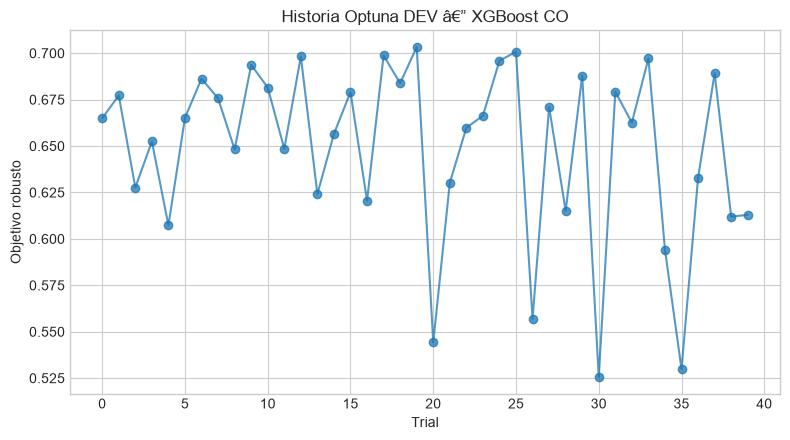

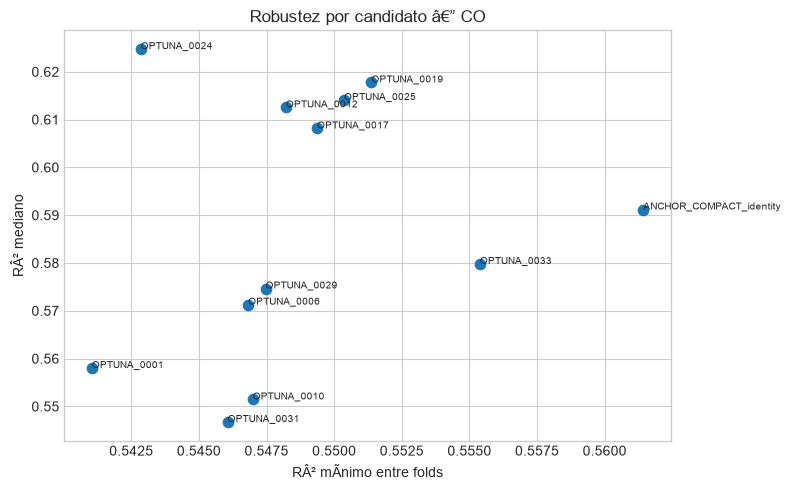

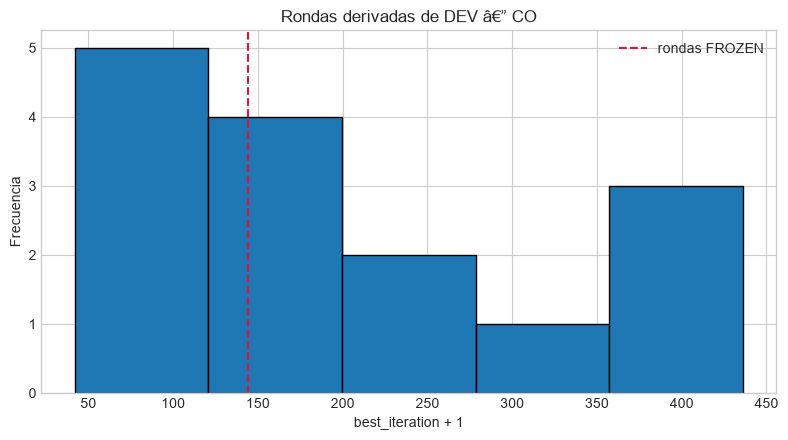

In [18]:
# [C-08.02] Figuras DEV-only
plt.style.use("seaborn-v0_8-whitegrid")

complete_view = TRIALS_TABLE.loc[TRIALS_TABLE.state.eq("COMPLETE")].copy()
if not complete_view.empty and "value" in complete_view:
    figure, axis = plt.subplots(figsize=(8, 4.5))
    axis.plot(complete_view.trial_number, complete_view.value, "o-", alpha=0.75)
    axis.set(
        title=f"Historia Optuna DEV — XGBoost {TARGET}",
        xlabel="Trial",
        ylabel="Objetivo robusto",
    )
    figure.tight_layout()
    figure.savefig(
        PATHS.figures / "01_historia_optuna_dev.png",
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()

if not DEVELOPMENT_RANKING.empty:
    view = DEVELOPMENT_RANKING.head(12).sort_values("R2_min")
    figure, axis = plt.subplots(figsize=(8, 5))
    axis.scatter(view.R2_min, view.R2_median, s=55)
    for _, row in view.iterrows():
        axis.annotate(str(row.candidate_id), (row.R2_min, row.R2_median), fontsize=7)
    axis.set(
        title=f"Robustez por candidato — {TARGET}",
        xlabel="R² mínimo entre folds",
        ylabel="R² mediano",
    )
    figure.tight_layout()
    figure.savefig(
        PATHS.figures / "02_robustez_candidatos_dev.png",
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()

if RUN_MODE == "FULL_AUTO":
    figure, axis = plt.subplots(figsize=(8, 4.5))
    axis.hist(champion_folds.effective_trees, bins="auto", edgecolor="black")
    axis.axvline(
        FINAL_TRAINING_POLICY["final_n_estimators"],
        color="crimson",
        linestyle="--",
        label="rondas FROZEN",
    )
    axis.set(
        title=f"Rondas derivadas de DEV — {TARGET}",
        xlabel="best_iteration + 1",
        ylabel="Frecuencia",
    )
    axis.legend()
    figure.tight_layout()
    figure.savefig(
        PATHS.figures / "03_rondas_finales_dev.png",
        dpi=160,
        bbox_inches="tight",
    )
    plt.show()


### C-08.03 / ART-06 — Informe, hashes y cierre

**Salida:** inventario verificable de artefactos y declaración explícita de
que TEST permaneció cerrado.


In [19]:
# [C-08.03] Persistencia terminal y resumen
report = f"""# Optimización XGBoost {TARGET} walk-forward R1

- Modo ejecutado: {RUN_MODE}.
- Dispositivo: {DEVICE}.
- Paralelismo: XGBoost interno con {XGB_N_JOBS} hilo(s); Optuna serial.
- Trials intentados: {attempted_trials(study)}.
- Trials completos: {complete_trials(study)}.
- Anchors activos: {len(ACTIVE_ANCHOR_CONFIGS)}.
- Folds por anchor/trial: WF01–WF03 completos.
- Filas objetivo 2015 materializadas: 0.
- Filas feature 2015 materializadas: 0.
- Hash de contenido 2015 calculado: no.
- Modelo: gbtree/hist, RAW_9, exclusivamente data-driven.
- Restricciones monotónicas: ninguna.
- Estado FROZEN: {RUN_MODE == 'FULL_AUTO' and FROZEN_MANIFEST is not None}.

Los resultados de validación caracterizan transferencia prospectiva entre
fronteras anuales de 2012, 2013 y 2014. No constituyen una evaluación de 2015,
no demuestran causalidad ni equivalen a conformidad regulatoria.
"""
atomic_text(
    PATHS.reports / "INFORME_TECNICO_XGBOOST_CO_WF_OPT_R1.md",
    report,
)

artifact_paths = [
    path
    for path in sorted(PATHS.work.rglob("*"))
    if path.is_file() and not path.name.startswith("HASHES_")
]
ARTIFACT_HASHES = pd.DataFrame(
    [
        {
            "path": str(path.relative_to(PATHS.work)).replace("\\", "/"),
            "bytes": path.stat().st_size,
            "sha256": sha256_file(path),
        }
        for path in artifact_paths
    ]
)
atomic_csv(
    PATHS.audit / "HASHES_XGBOOST_CO_WF_OPT_R1.csv",
    ARTIFACT_HASHES,
)
print(
    {
        "estado": "FROZEN" if FROZEN_MANIFEST else "SMOKE_COMPLETE",
        "test_target_rows_materialized": 0,
        "test_feature_rows_materialized": 0,
        "test_content_hashed": False,
        "artefactos": len(ARTIFACT_HASHES),
        "salida": str(PATHS.work),
    }
)

{'estado': 'FROZEN', 'test_target_rows_materialized': 0, 'test_feature_rows_materialized': 0, 'test_content_hashed': False, 'artefactos': 26, 'salida': 'C:\\ChatGPT-Work\\Walk_Forward R8\\models\\wf\\work_xgboost_co_wf_opt_r1_poc_efficient'}


## OUT-01 — Registro de versión

**R1:** adaptación funcional de la fuente XGBoost CO R1 al contrato
walk-forward. Cambian el escenario, los folds, las rutas y la barrera de 2015;
se conserva el modelo puramente data-driven y el espacio XGBoost.